<a href="https://colab.research.google.com/github/Zalcom53/Reconocimiento-de-patrones/blob/main/Predict_the_Introverts_from_the_Extroverts.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All"
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

Train shape: (18524, 9)
Test shape: (6175, 8)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18524 entries, 0 to 18523
Data columns (total 9 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   id                         18524 non-null  int64  
 1   Time_spent_Alone           17334 non-null  float64
 2   Stage_fear                 16631 non-null  object 
 3   Social_event_attendance    17344 non-null  float64
 4   Going_outside              17058 non-null  float64
 5   Drained_after_socializing  17375 non-null  object 
 6   Friends_circle_size        17470 non-null  float64
 7   Post_frequency             17260 non-null  float64
 8   Personality                18524 non-null  object 
dtypes: float64(5), int64(1), object(3)
memory usage: 1.3+ MB
None
id                              0
Time_spent_Alone             1190
Stage_fear                   1893
Social_event_attendance      1180
Going_outside              

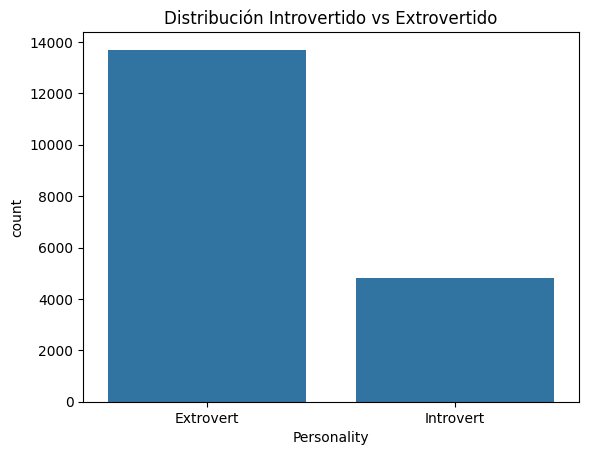

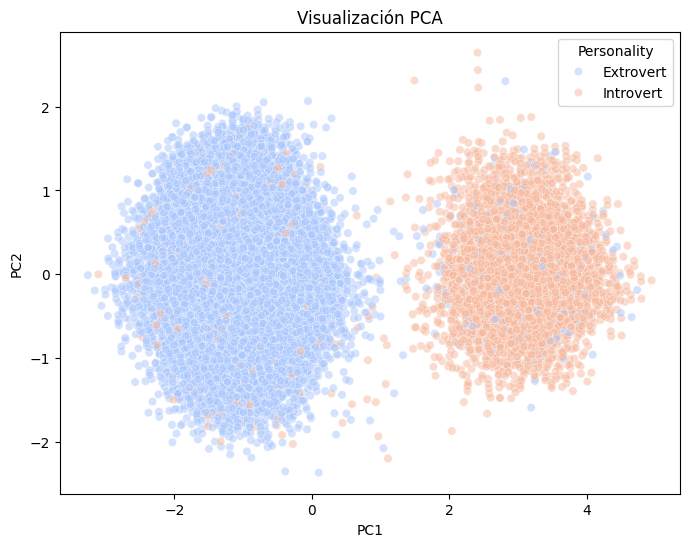

Accuracy baseline: 0.9689608636977058

Classification report:
               precision    recall  f1-score   support

   Extrovert       0.98      0.98      0.98      2740
   Introvert       0.93      0.95      0.94       965

    accuracy                           0.97      3705
   macro avg       0.96      0.96      0.96      3705
weighted avg       0.97      0.97      0.97      3705



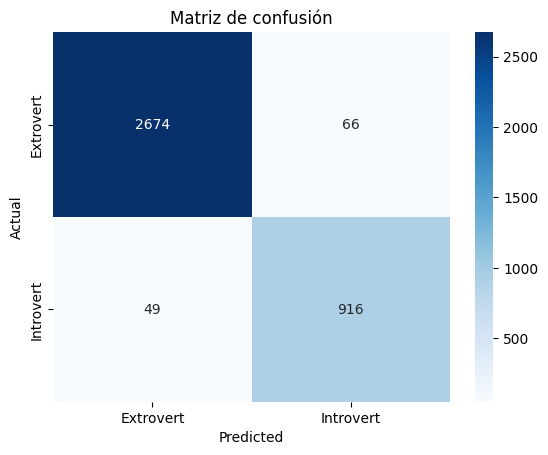

Mejores parámetros: {'classifier__n_estimators': 100, 'classifier__min_samples_split': 2, 'classifier__max_depth': 5}
Accuracy final: 0.9711201079622133
Archivo submission.csv generado listo para subir a Kaggle


In [6]:

# Predict the Introverts from the Extroverts
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, RandomizedSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.decomposition import PCA
from sklearn.impute import SimpleImputer

# -----------------------------------------
#  Cargar los datos
train = pd.read_csv('train.csv')
test = pd.read_csv('test.csv')
sample_submission = pd.read_csv('sample_submission.csv')

print("Train shape:", train.shape)
print("Test shape:", test.shape)
train.head()

# -----------------------------------------
#  Análisis exploratorio sencillo (EDA)
print(train.info())
print(train.isnull().sum())
print(train.describe())

# Visualización de la distribución de la variable objetivo
sns.countplot(x='Personality', data=train)
plt.title("Distribución Introvertido vs Extrovertido")
plt.show()

# -----------------------------------------
# Preparar features y target
X = train.drop('Personality', axis=1)
y = train['Personality']

# Columnas numéricas y categóricas
numeric_features = ['Time_spent_Alone', 'Social_event_attendance', 'Going_outside', 'Friends_circle_size', 'Post_frequency']
categorical_features = ['Stage_fear', 'Drained_after_socializing']

# -----------------------------------------
# Pipeline de preprocesamiento con imputación
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='mean')),   # Imputa con la media
    ('scaler', StandardScaler())                   # Escala numéricas
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')), # Imputa con moda
    ('onehot', OneHotEncoder(handle_unknown='ignore'))    # Codifica categóricas
])

preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer, numeric_features),
    ('cat', categorical_transformer, categorical_features)
])

# -----------------------------------------
# PCA para visualización
X_preprocessed = preprocessor.fit_transform(X)  # Aplica imputación y escalado/codificación

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_preprocessed)

plt.figure(figsize=(8,6))
sns.scatterplot(x=X_pca[:,0], y=X_pca[:,1], hue=y, palette='coolwarm', alpha=0.5)
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('Visualización PCA')
plt.show()

# -----------------------------------------
# Pipeline completo con Random Forest
pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(random_state=42))
])

# -----------------------------------------
# Dividir datos para entrenamiento/validación
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Entrenar modelo baseline
pipeline.fit(X_train, y_train)
y_pred = pipeline.predict(X_val)

print("Accuracy baseline:", accuracy_score(y_val, y_pred))
print("\nClassification report:\n", classification_report(y_val, y_pred))

# Matriz de confusión
cm = confusion_matrix(y_val, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Extrovert','Introvert'], yticklabels=['Extrovert','Introvert'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Matriz de confusión')
plt.show()

# -----------------------------------------
# Búsqueda de hiperparámetros
param_grid = {
    'classifier__n_estimators': [100, 200, 300],
    'classifier__max_depth': [None, 5, 10],
    'classifier__min_samples_split': [2, 5, 10]
}

search = RandomizedSearchCV(pipeline, param_distributions=param_grid, n_iter=10, cv=3, scoring='accuracy', random_state=42, n_jobs=-1)
search.fit(X_train, y_train)
print("Mejores parámetros:", search.best_params_)

# Evaluación final con mejor modelo
y_pred_final = search.predict(X_val)
print("Accuracy final:", accuracy_score(y_val, y_pred_final))

# -----------------------------------------
# Predicción en test y submission
test_preds = search.predict(test)

submission = pd.DataFrame({
    'id': test['id'],
    'Personality': test_preds
})

submission.to_csv('submission.csv', index=False)
print("Archivo submission.csv generado listo para subir a Kaggle")
